# Sistema dinámico de recomendación basado en likes simulados

Este notebook estudia la capa dinámica del recomendador. A partir de embeddings ya calculados, se construye un perfil vectorial con likes simulados, se recomienda por similitud coseno y se comparan mejoras de diversidad y feedback negativo.


## 1. Carga de artefactos y control de consistencia

El notebook intenta cargar `artifacts/embeddings_posts.joblib`. Si el artefacto está desactualizado respecto a `data/posts.csv`, lo regenera usando el modelo local de SentenceTransformers. Esto evita analizar recomendaciones sobre un dataset antiguo.


In [1]:
import re
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics.pairwise import cosine_similarity

ARTIFACTS_PATH = Path("artifacts/embeddings_posts.joblib")
EMBEDDING_METADATA_PATH = Path("models/clasificador_embeddings.joblib")
EMBEDDING_MODEL_DIR = Path("models/modelo_embeddings")
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
DATA_PATH = Path("data/posts.csv")

TOP_K = 10
LAMBDA_DIVERSIDAD_DEFECTO = 0.04
LAMBDAS_A_PROBAR = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10]
RANDOM_STATE = 42
MIN_TOKENS_RECOMMENDABLE = 4

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 40)


In [2]:
REQUIRED_COLUMNS = ["id", "descripcion", "hashtags", "categoria"]
OPTIONAL_COLUMNS = [
    "categoria_generadora", "categoria_secundaria", "es_ambiguo", "tipo_post",
    "nivel_ruido", "etiqueta_ruidosa", "entidades",
]


def preprocesar_texto(texto: str) -> str:
    texto = str(texto).lower().replace("#", " ")
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def preparar_texto_embedding(texto: str) -> str:
    texto = str(texto).replace("#", " ")
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def preparar_dataframe_posts():
    df = pd.read_csv(DATA_PATH, encoding="utf-8")
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Faltan columnas obligatorias: {missing_columns}")

    available_optional_columns = [column for column in OPTIONAL_COLUMNS if column in df.columns]
    df = df[REQUIRED_COLUMNS + available_optional_columns].copy()
    df["texto_original"] = (
        df["descripcion"].fillna("").astype(str).str.strip()
        + " "
        + df["hashtags"].fillna("").astype(str).str.replace("#", " #", regex=False).str.strip()
    ).str.replace(r"\s+", " ", regex=True).str.strip()
    df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
    df["texto_embedding"] = df["texto_original"].apply(preparar_texto_embedding)
    return df, df[df["texto_embedding"].str.len() > 0].copy().reset_index(drop=True)


def regenerar_embeddings():
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as exc:
        raise ImportError("No hay artefacto válido y falta sentence-transformers para regenerarlo.") from exc

    df_raw, df_modelo_local = preparar_dataframe_posts()
    if EMBEDDING_MODEL_DIR.exists():
        modelo = SentenceTransformer(str(EMBEDDING_MODEL_DIR), local_files_only=True)
    else:
        modelo = SentenceTransformer(EMBEDDING_MODEL_NAME)
        modelo.save(str(EMBEDDING_MODEL_DIR))

    embeddings = modelo.encode(
        df_modelo_local["texto_embedding"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)

    post_columns = [
        column for column in [
            "id", "descripcion", "hashtags", "categoria", "categoria_generadora",
            "categoria_secundaria", "es_ambiguo", "tipo_post", "nivel_ruido",
            "etiqueta_ruidosa", "entidades", "texto_original", "texto_limpio", "texto_embedding",
        ] if column in df_modelo_local.columns
    ]
    artefacto_local = {
        "embeddings": embeddings,
        "posts": df_modelo_local[post_columns].copy(),
        "embedding_model_name": EMBEDDING_MODEL_NAME,
        "embedding_model_dir": str(EMBEDDING_MODEL_DIR),
        "text_column": "texto_embedding",
        "data_path": str(DATA_PATH),
        "source_dataset_rows": int(len(df_raw)),
        "source_model_rows": int(len(df_modelo_local)),
    }
    ARTIFACTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(artefacto_local, ARTIFACTS_PATH)
    return artefacto_local, "embeddings regenerados desde el CSV actual"


df_raw_actual, df_modelo_actual = preparar_dataframe_posts()
origen_carga = ""

try:
    artefacto = joblib.load(ARTIFACTS_PATH)
    required_keys = {"embeddings", "posts"}
    if not required_keys.issubset(artefacto):
        raise ValueError(f"Claves insuficientes en artefacto: {sorted(artefacto.keys())}")

    if artefacto.get("source_dataset_rows") != len(df_raw_actual):
        raise ValueError("El artefacto corresponde a otro tamaño de dataset.")

    embeddings_posts = np.asarray(artefacto["embeddings"], dtype=np.float32)
    df_modelo = artefacto["posts"].copy().reset_index(drop=True)
    origen_carga = f"artefacto persistido en {ARTIFACTS_PATH}"
except Exception as exc:
    artefacto, origen_carga = regenerar_embeddings()
    origen_carga = f"{origen_carga}; motivo: {exc.__class__.__name__}"
    embeddings_posts = np.asarray(artefacto["embeddings"], dtype=np.float32)
    df_modelo = artefacto["posts"].copy().reset_index(drop=True)

required_columns = {"texto_limpio", "texto_embedding", "categoria"}
if not required_columns.issubset(df_modelo.columns):
    raise ValueError(f"df_modelo debe incluir {required_columns}. Columnas: {df_modelo.columns.tolist()}")

if len(df_modelo) != len(embeddings_posts):
    raise ValueError(f"Filas y embeddings no coinciden: {len(df_modelo)} vs {len(embeddings_posts)}")

embeddings_norm = embeddings_posts / np.clip(np.linalg.norm(embeddings_posts, axis=1, keepdims=True), 1e-12, None)
df_modelo["longitud_texto"] = df_modelo["texto_limpio"].str.split().str.len()
embedding_model_name = artefacto.get("embedding_model_name", EMBEDDING_MODEL_NAME)
embedding_model_dir = Path(artefacto.get("embedding_model_dir", EMBEDDING_MODEL_DIR))

print(f"Origen de carga: {origen_carga}")
print(f"Modelo de embeddings: {embedding_model_name}")
print(f"Matriz de embeddings: {embeddings_norm.shape[0]} posts x {embeddings_norm.shape[1]} dimensiones")
display(df_modelo[["categoria", "texto_embedding"]].head())


Origen de carga: artefacto persistido en artifacts\embeddings_posts.joblib
Modelo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Matriz de embeddings: 10873 posts x 384 dimensiones


,categoria,texto_embedding
0,deporte,plan improvisado: despues del gym cayo MasterChef porque el cuerpo lo pidio random pero necesario cocina partido
1,viajes,mini update: vuelo temprano con cafe dudoso sin filtros y con prisa 🎸 gymbro escapada top
2,viajes,vuelo temprano con cafe dudoso en Londres con camara Travel
3,playa,"vibe de hoy: baño rapido antes de comer, que locura jajaja Random Verano"
4,playa,"vibe de hoy: brisa salada y cero prisa, ns q decir jaja sol"


## 2. Diagnóstico del dataset para recomendación

Antes de recomendar, se comprueba si el corpus favorece rankings homogéneos: categorías con muchos ejemplos, alta cohesión interna o pares de categorías demasiado próximos.


Número de categorías: 8
Ratio de desbalance max/min: 1.82


,categoria,n_posts,porcentaje
0,viajes,1912,17.58
1,playa,1571,14.45
2,musica,1528,14.05
3,deporte,1268,11.66
4,coches,1256,11.55
5,cocina,1222,11.24
6,videojuegos,1064,9.79
7,animales,1052,9.68


,categoria,n_posts,longitud_media,longitud_mediana,longitud_std
6,viajes,1912,17.74,18.0,7.39
5,playa,1571,17.10,17.0,7.60
4,musica,1528,17.52,17.0,7.44
3,deporte,1268,16.96,17.0,7.22
1,coches,1256,17.54,17.0,7.72
2,cocina,1222,16.70,17.0,7.44
7,videojuegos,1064,17.51,18.0,7.37
0,animales,1052,17.30,17.0,7.54


,n_posts,tasa_ambiguedad
categoria,,
viajes,1912,0.539
musica,1528,0.460
playa,1571,0.445
cocina,1222,0.406
coches,1256,0.402
deporte,1268,0.401
animales,1052,0.330
videojuegos,1064,0.316


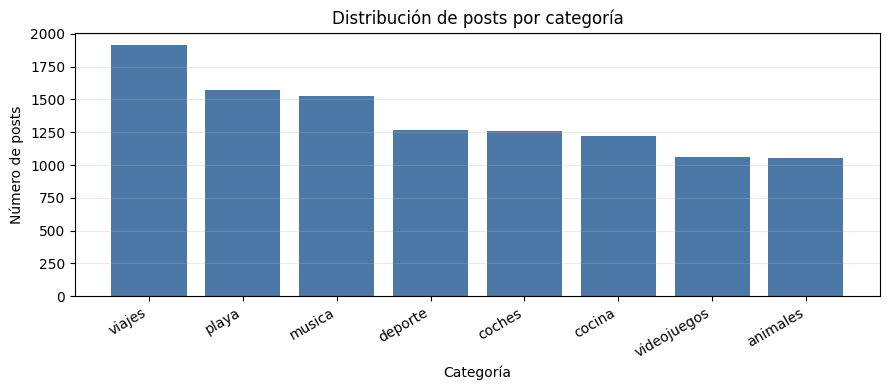

In [3]:
conteo_categorias = df_modelo["categoria"].value_counts().rename_axis("categoria").reset_index(name="n_posts")
conteo_categorias["porcentaje"] = (100 * conteo_categorias["n_posts"] / len(df_modelo)).round(2)

longitud_por_categoria = (
    df_modelo.groupby("categoria")["longitud_texto"]
    .agg(n_posts="size", longitud_media="mean", longitud_mediana="median", longitud_std="std")
    .round(2)
    .reset_index()
    .sort_values("n_posts", ascending=False)
)

n_categorias = df_modelo["categoria"].nunique()
ratio_desbalance = conteo_categorias["n_posts"].max() / conteo_categorias["n_posts"].min()

print(f"Número de categorías: {n_categorias}")
print(f"Ratio de desbalance max/min: {ratio_desbalance:.2f}")
display(conteo_categorias)
display(longitud_por_categoria)

if "es_ambiguo" in df_modelo.columns:
    resumen_ambiguedad = (
        df_modelo.groupby("categoria")["es_ambiguo"]
        .agg(n_posts="size", tasa_ambiguedad="mean")
        .sort_values("tasa_ambiguedad", ascending=False)
    )
    resumen_ambiguedad["tasa_ambiguedad"] = resumen_ambiguedad["tasa_ambiguedad"].round(3)
    display(resumen_ambiguedad)

plt.figure(figsize=(9, 4))
plt.bar(conteo_categorias["categoria"], conteo_categorias["n_posts"], color="#4C78A8")
plt.title("Distribución de posts por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de posts")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [4]:
print("Muestras de textos por categoría:")
for categoria in sorted(df_modelo["categoria"].unique()):
    muestras = (
        df_modelo[df_modelo["categoria"].eq(categoria)][["texto_embedding"]]
        .sample(min(3, df_modelo["categoria"].eq(categoria).sum()), random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    print(f"\nCategoría: {categoria}")
    display(muestras)


Muestras de textos por categoría:

Categoría: animales


,texto_embedding
0,mini update: visita al veterinario sin drama; luego en plan tranquilo y acabamos hablando de madrid ☀️ Gatos Paseo
1,"gato durmiendo encima del teclado cerca de lugo. despues de una semana eterna, max de fondo y no pido mas 🎸 petfriendly vibes"
2,"bro despues de mil vueltas, atardecer cerca del mar con paseo largo y cero prisa. No encaja perfecto en una sola categoria, porque mezcl..."



Categoría: coches


,texto_embedding
0,"si esto no es felicidad entonces nada ruta larga con el Ferrari, maleta atras y cero ganas de llegar, sin planear demasiado me renta dem..."
1,"no se como explicar esto pero viaje en coche por la costa, gps perdido y cafe de gasolinera top que fantasía 💀 Ruta"
2,roadtrip



Categoría: cocina


...

,texto_embedding
0,nadie me preparo para paseo por calas de Paris despues de perder el bus del hotel muy de hoy destino
1,"nadie me preparo para briisa salada y cero prisa. entre camara, mensajes sin responder y formentera, el plan quedo raro pero top ✨!!! fy..."
2,calas pequeñas sin cobertura en pontevedra con protector solar 🌊... costa atardecer



Categoría: viajes


,texto_embedding
0,"paseo por calas de Murcia despues de perder el bus del hotel, entre risas y cero cobertura random pero necesario wanderlust mar turismo"
1,me desperte penando en esto: Nala random 🏋️ vibes
2,mapa abierto y cero orientacion; luego porque a veces sale bien sin pensarlo y acabamos hablando de ibiza 🎮 Trabajo



Categoría: videojuegos


,texto_embedding
0,vibe de hoy: GTA no puedo mas ⚽ Gamer StudyTok
1,Xbox: setup mdeio ordenado para variar y me renta demasiado 🎧 Twitch
2,"mini update: jugando al fortnite escuchando aitana hasta que se fue el lag, sin planear demasiado festival fifa"


### Similitud intra e inter categoría

La similitud media intra-categoría mide cuánto se parecen posts de la misma clase. La inter-categoría mide cercanía entre clases diferentes. La brecha entre ambas ayuda a explicar si el ranking tenderá a concentrarse.


In [5]:
def similitud_intra_media_exacta(indices):
    vectores = embeddings_norm[indices]
    n = len(vectores)
    if n < 2:
        return np.nan
    suma = vectores.sum(axis=0)
    suma_pares = float(np.dot(suma, suma) - n)
    return suma_pares / (n * (n - 1))


def similitud_inter_media_exacta(indices_a, indices_b):
    vectores_a = embeddings_norm[indices_a]
    vectores_b = embeddings_norm[indices_b]
    return float(np.dot(vectores_a.mean(axis=0), vectores_b.mean(axis=0)))


indices_por_categoria = {
    categoria: df_modelo.index[df_modelo["categoria"].eq(categoria)].to_numpy()
    for categoria in sorted(df_modelo["categoria"].unique())
}

filas_intra = []
for categoria, indices in indices_por_categoria.items():
    filas_intra.append(
        {
            "categoria": categoria,
            "n_posts": len(indices),
            "similitud_media_intra": similitud_intra_media_exacta(indices),
        }
    )

df_similitud_intra = pd.DataFrame(filas_intra).sort_values("similitud_media_intra", ascending=False)
df_similitud_intra["similitud_media_intra"] = df_similitud_intra["similitud_media_intra"].round(4)

filas_inter = []
for categoria_a, categoria_b in combinations(indices_por_categoria.keys(), 2):
    filas_inter.append(
        {
            "categoria_a": categoria_a,
            "categoria_b": categoria_b,
            "similitud_media_inter": similitud_inter_media_exacta(
                indices_por_categoria[categoria_a],
                indices_por_categoria[categoria_b],
            ),
        }
    )

df_similitud_inter = pd.DataFrame(filas_inter).sort_values("similitud_media_inter", ascending=False)
df_similitud_inter["similitud_media_inter"] = df_similitud_inter["similitud_media_inter"].round(4)

similitud_intra_global = float(
    np.average(df_similitud_intra["similitud_media_intra"], weights=df_similitud_intra["n_posts"])
)
similitud_inter_global = float(df_similitud_inter["similitud_media_inter"].mean())
separacion_intra_inter = similitud_intra_global - similitud_inter_global

display(df_similitud_intra)
display(df_similitud_inter.head(12))
print(f"Similitud intra global ponderada: {similitud_intra_global:.4f}")
print(f"Similitud inter global media: {similitud_inter_global:.4f}")
print(f"Separación intra - inter: {separacion_intra_inter:.4f}")


,categoria,n_posts,similitud_media_intra
2,cocina,1222,0.4087
6,viajes,1912,0.4075
1,coches,1256,0.3975
5,playa,1571,0.3974
0,animales,1052,0.3946
4,musica,1528,0.3832
7,videojuegos,1064,0.3757
3,deporte,1268,0.3588


,categoria_a,categoria_b,similitud_media_inter
25,playa,viajes,0.3543
11,coches,viajes,0.3441
15,cocina,playa,0.3319
24,musica,videojuegos,0.3314
4,animales,playa,0.3299
5,animales,viajes,0.3260
22,musica,playa,0.3216
13,cocina,deporte,0.3128
16,cocina,viajes,0.3096
10,coches,playa,0.3060


Similitud intra global ponderada: 0.3916
Similitud inter global media: 0.2984
Separación intra - inter: 0.0932


In [6]:
if separacion_intra_inter > 0.08:
    lectura_separacion = "alta"
elif separacion_intra_inter > 0.03:
    lectura_separacion = "moderada"
else:
    lectura_separacion = "baja"

categoria_mas_compacta = df_similitud_intra.iloc[0]
par_mas_cercano = df_similitud_inter.iloc[0]

texto_diagnostico = f'''
**Lectura específica del dataset cargado**

- La similitud intra-categoría global es `{similitud_intra_global:.4f}` y la inter-categoría media es `{similitud_inter_global:.4f}`. La separación observada es `{separacion_intra_inter:.4f}`, por lo que la separabilidad semántica es **{lectura_separacion}**.
- La categoría con mayor cohesión interna es `{categoria_mas_compacta['categoria']}` con similitud `{categoria_mas_compacta['similitud_media_intra']:.4f}`.
- El par de categorías más cercano es `{par_mas_cercano['categoria_a']}` - `{par_mas_cercano['categoria_b']}` con similitud `{par_mas_cercano['similitud_media_inter']:.4f}`.
- El ratio de desbalance max/min es `{ratio_desbalance:.2f}`.
'''

display(Markdown(texto_diagnostico))



**Lectura específica del dataset cargado**

- La similitud intra-categoría global es `0.3916` y la inter-categoría media es `0.2984`. La separación observada es `0.0932`, por lo que la separabilidad semántica es **alta**.
- La categoría con mayor cohesión interna es `cocina` con similitud `0.4087`.
- El par de categorías más cercano es `playa` - `viajes` con similitud `0.3543`.
- El ratio de desbalance max/min es `1.82`.


## 3. Funciones de recomendación y evaluación

La línea base ordena por similitud coseno. La variante diversa mantiene la similitud como criterio principal, pero penaliza repetir categorías ya seleccionadas.


In [7]:
def normalizar_vector(vector):
    vector = np.asarray(vector, dtype=np.float32)
    if vector.ndim == 1:
        vector = vector.reshape(1, -1)
    norma = np.linalg.norm(vector, axis=1, keepdims=True)
    norma[norma == 0] = 1.0
    return vector / norma


def score_candidato_like(fila):
    tipo_preferencia = {"medium": 0, "long": 1, "short": 2, "micro": 3, "outlier": 4}
    ruido_preferencia = {"bajo": 0, "medio": 1, "alto": 2}
    tipo = tipo_preferencia.get(fila.get("tipo_post", "medium"), 2)
    ruido = ruido_preferencia.get(fila.get("nivel_ruido", "medio"), 1)
    etiqueta_ruidosa = int(bool(fila.get("etiqueta_ruidosa", False)))
    longitud = int(fila.get("longitud_texto", 0))
    distancia_longitud = abs(longitud - 18)
    muy_corto = int(longitud < MIN_TOKENS_RECOMMENDABLE)
    return (muy_corto, etiqueta_ruidosa, tipo, ruido, distancia_longitud)


def primer_indice_disponible(categoria, usados):
    candidatos = df_modelo[df_modelo["categoria"].eq(categoria)].copy()
    candidatos = candidatos[~candidatos.index.isin(usados)].copy()
    if candidatos.empty:
        raise ValueError(f"No quedan posts disponibles para la categor?a: {categoria}")

    candidatos["score_like"] = candidatos.apply(score_candidato_like, axis=1)
    candidatos = candidatos.sort_values(["score_like", "id" if "id" in candidatos.columns else "longitud_texto"])
    return int(candidatos.index[0])


def obtener_indices_likes(categorias_likes):
    usados = set()
    indices = []
    for categoria in categorias_likes:
        indice = primer_indice_disponible(categoria, usados)
        indices.append(indice)
        usados.add(indice)
    return indices


def construir_perfil_media(indices_likeados):
    perfil = embeddings_norm[indices_likeados].mean(axis=0, keepdims=True)
    return normalizar_vector(perfil)


def construir_perfil_con_dislikes(indices_likes, indices_dislikes, alpha=0.5):
    perfil_likes = embeddings_norm[indices_likes].mean(axis=0, keepdims=True)
    perfil_dislikes = embeddings_norm[indices_dislikes].mean(axis=0, keepdims=True)
    perfil = perfil_likes - alpha * perfil_dislikes
    return normalizar_vector(perfil)


def columnas_recomendacion():
    return [
        column for column in [
            "texto_embedding", "texto_limpio", "categoria", "categoria_secundaria",
            "es_ambiguo", "nivel_ruido", "tipo_post", "entidades",
        ] if column in df_modelo.columns
    ]


def mascara_candidatos_recomendables(indices_excluidos):
    mascara = np.ones(len(df_modelo), dtype=bool)
    mascara[list(indices_excluidos)] = False
    mascara &= df_modelo["longitud_texto"].to_numpy() >= MIN_TOKENS_RECOMMENDABLE
    if "tipo_post" in df_modelo.columns:
        mascara &= ~df_modelo["tipo_post"].eq("outlier").to_numpy()
    return mascara


def recomendar_base(perfil_usuario, indices_excluidos, top_k=TOP_K):
    similitudes = cosine_similarity(perfil_usuario, embeddings_norm).ravel()
    mascara = mascara_candidatos_recomendables(indices_excluidos)

    recomendaciones = df_modelo.loc[mascara, columnas_recomendacion()].copy()
    recomendaciones["score_similitud"] = similitudes[mascara]
    recomendaciones["indice"] = np.flatnonzero(mascara)
    recomendaciones = recomendaciones.sort_values("score_similitud", ascending=False).head(top_k).copy()
    return recomendaciones.reset_index(drop=True)


def recomendar_con_diversidad(perfil_usuario, indices_excluidos, top_k=TOP_K, lambda_diversidad=LAMBDA_DIVERSIDAD_DEFECTO):
    similitudes = cosine_similarity(perfil_usuario, embeddings_norm).ravel()
    mascara = mascara_candidatos_recomendables(indices_excluidos)
    candidatos = df_modelo.loc[mascara, columnas_recomendacion()].copy()
    candidatos["score_similitud"] = similitudes[mascara]
    candidatos["indice"] = np.flatnonzero(mascara)

    seleccionados = []
    repeticiones_categoria = {}

    for _ in range(min(top_k, len(candidatos))):
        candidatos = candidatos.copy()
        candidatos["repeticiones_categoria"] = candidatos["categoria"].map(repeticiones_categoria).fillna(0).astype(int)
        candidatos["score_final"] = candidatos["score_similitud"] - lambda_diversidad * candidatos["repeticiones_categoria"]

        idx_mejor = candidatos["score_final"].idxmax()
        fila = candidatos.loc[idx_mejor].copy()
        seleccionados.append(fila)

        categoria = fila["categoria"]
        repeticiones_categoria[categoria] = repeticiones_categoria.get(categoria, 0) + 1
        candidatos = candidatos.drop(index=idx_mejor)

    return pd.DataFrame(seleccionados).reset_index(drop=True)


def precision_at_k(recomendaciones, categorias_relevantes):
    return float(recomendaciones["categoria"].isin(set(categorias_relevantes)).mean())


def diversidad_at_k(recomendaciones):
    return int(recomendaciones["categoria"].nunique())


def ambiguedad_at_k(recomendaciones):
    if "es_ambiguo" not in recomendaciones.columns:
        return np.nan
    return float(recomendaciones["es_ambiguo"].mean())


def score_medio(recomendaciones):
    return float(recomendaciones["score_similitud"].mean())


def overlap_rankings(recomendaciones_a, recomendaciones_b):
    indices_a = set(recomendaciones_a["indice"].tolist())
    indices_b = set(recomendaciones_b["indice"].tolist())
    return len(indices_a.intersection(indices_b)) / min(len(indices_a), len(indices_b))


def evaluar_recomendaciones(nombre, recomendaciones, categorias_relevantes):
    return {
        "estrategia": nombre,
        f"precision_at_{len(recomendaciones)}": round(precision_at_k(recomendaciones, categorias_relevantes), 3),
        f"diversidad_at_{len(recomendaciones)}": diversidad_at_k(recomendaciones),
        f"ambiguedad_at_{len(recomendaciones)}": round(ambiguedad_at_k(recomendaciones), 3),
        "score_medio": round(score_medio(recomendaciones), 4),
        "categorias_recomendadas": " | ".join(recomendaciones["categoria"].tolist()),
    }


## 4. Recomendación simple base

La línea base permite observar la tendencia natural del sistema: si el perfil está cerca de una categoría compacta, el top-k puede quedar muy concentrado.


In [8]:
categorias_likes_base = ["playa", "playa", "viajes"]
indices_likes_base = obtener_indices_likes(categorias_likes_base)
perfil_base = construir_perfil_media(indices_likes_base)

print("Likes iniciales usados para la línea base:")
display(df_modelo.loc[indices_likes_base, columnas_recomendacion()].reset_index(drop=True))

recomendaciones_base = recomendar_base(perfil_base, indices_likes_base, top_k=TOP_K)
print("Top-k por similitud coseno:")
display(recomendaciones_base[[
    column for column in [
        "texto_embedding", "categoria", "categoria_secundaria", "es_ambiguo",
        "nivel_ruido", "score_similitud",
    ] if column in recomendaciones_base.columns
]])


Likes iniciales usados para la línea base:


,texto_embedding,texto_limpio,categoria,categoria_secundaria,es_ambiguo,nivel_ruido,tipo_post,entidades
0,"literalmente vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena asi si cafe mar",literalmente vacaciones con musica playa y maleta medio rota en cadiz con gente buena asi si cafe mar,playa,viajes,True,bajo,medium,NaN
1,"Tenerife aparecio en el plan: baño rapido antes de comer, con ganas de repetir, altavoz incluido!!! Calas Aesthetic",tenerife aparecio en el plan baño rapido antes de comer con ganas de repetir altavoz incluido calas aesthetic,playa,NaN,False,bajo,medium,Tenerife
2,vibe de hoy: mapa abierto y cero orientacion en Londres con coche; sin planear demasiado y turismo gymbro,vibe de hoy mapa abierto y cero orientacion en londres con coche sin planear demasiado y turismo gymbro,viajes,NaN,False,bajo,medium,NaN


Top-k por similitud coseno:


,texto_embedding,categoria,categoria_secundaria,es_ambiguo,nivel_ruido,score_similitud
0,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres bro esto esta increible relax domingo mar aventura",playa,viajes,True,bajo,0.819213
1,"despues de mil vueltas, vacaciones con musica, playa y maleta medio rota en Londres, en plan tranquilo no pido mas JAJA SinFiltros Turismo",playa,viajes,True,bajo,0.818866
2,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres muy de hoy 🐶 relax destino vibes",playa,viajes,True,bajo,0.818465
3,"plan improvisado: vacaciones con musica, playa y maleta medio rota en granada, sin filtros y con prisa top Atardecer Escapada",playa,viajes,True,medio,0.800742
4,"vibe de hoy: vacaciones con musica, playa y maleta medio rota en valencia y bueno Oferta",viajes,playa,True,alto,0.797932
5,"me desperte pensando en esto: vacaciones con musica, playa y maleta medio rota en Tenerife asi si Vibes Relax Turismo",playa,viajes,True,bajo,0.795942
6,"mini update: vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena escapada turismo",viajes,playa,True,bajo,0.794183
7,"literalmente vacaciones con musica, playa y maleta medio rota en Paris muy de hoy atardecer playa",playa,viajes,True,bajo,0.792347
8,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Lisboa random pero necesario relax",playa,viajes,True,medio,0.789939
9,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Las Palmas literalmente obsesionado ☀️",viajes,playa,True,bajo,0.785577


## 5. Recomendación con diversidad

La penalización por repetición de categoría introduce un trade-off: baja ligeramente la similitud media, pero aumenta cobertura y reduce listas redundantes.


In [9]:
filas_lambda = []
rankings_por_lambda = {}

for lambda_diversidad in LAMBDAS_A_PROBAR:
    recomendaciones = recomendar_con_diversidad(
        perfil_base,
        indices_likes_base,
        top_k=TOP_K,
        lambda_diversidad=lambda_diversidad,
    )
    rankings_por_lambda[lambda_diversidad] = recomendaciones
    filas_lambda.append(
        {
            "lambda_diversidad": lambda_diversidad,
            "precision_at_k": round(precision_at_k(recomendaciones, set(categorias_likes_base)), 3),
            "diversidad_at_k": diversidad_at_k(recomendaciones),
            "ambiguedad_at_k": round(ambiguedad_at_k(recomendaciones), 3),
            "score_medio": round(score_medio(recomendaciones), 4),
            "overlap_con_base": round(overlap_rankings(recomendaciones_base, recomendaciones), 3),
            "categorias_top_k": " | ".join(recomendaciones["categoria"].tolist()),
        }
    )

df_lambda = pd.DataFrame(filas_lambda)
display(df_lambda)

precision_base_lambda = df_lambda.loc[df_lambda["lambda_diversidad"].eq(0.0), "precision_at_k"].iloc[0]
score_base_lambda = df_lambda.loc[df_lambda["lambda_diversidad"].eq(0.0), "score_medio"].iloc[0]
candidatos_equilibrados = df_lambda[
    (df_lambda["lambda_diversidad"] > 0)
    & (df_lambda["precision_at_k"] >= precision_base_lambda - 0.30)
    & (df_lambda["score_medio"] >= score_base_lambda - 0.06)
].copy()

if candidatos_equilibrados.empty:
    lambda_equilibrado = LAMBDA_DIVERSIDAD_DEFECTO
else:
    lambda_equilibrado = float(
        candidatos_equilibrados.sort_values(
            ["diversidad_at_k", "score_medio", "precision_at_k"],
            ascending=[False, False, False],
        ).iloc[0]["lambda_diversidad"]
    )

print(f"Ranking con lambda_diversidad equilibrado = {lambda_equilibrado:.2f}:")
display(rankings_por_lambda[lambda_equilibrado][[
    column for column in [
        "texto_embedding", "categoria", "categoria_secundaria", "score_similitud", "score_final",
    ] if column in rankings_por_lambda[lambda_equilibrado].columns
]])


,lambda_diversidad,precision_at_k,diversidad_at_k,ambiguedad_at_k,score_medio,overlap_con_base,categorias_top_k
0,0.00,1.0,2,1.0,0.8013,1.0,playa | playa | playa | playa | viajes | playa | viajes | playa | playa | viajes
1,0.02,0.6,5,1.0,0.7914,0.6,playa | playa | viajes | playa | musica | coches | viajes | cocina | viajes | cocina
2,0.04,0.5,6,1.0,0.7840,0.5,playa | viajes | playa | musica | coches | cocina | viajes | playa | cocina | animales
3,0.06,0.5,6,1.0,0.7840,0.5,playa | viajes | musica | coches | cocina | playa | viajes | animales | cocina | playa
4,0.08,0.4,7,1.0,0.7705,0.4,playa | viajes | musica | coches | cocina | playa | viajes | animales | cocina | deporte
5,0.10,0.4,7,1.0,0.7705,0.4,playa | viajes | musica | coches | cocina | playa | animales | viajes | deporte | cocina


Ranking con lambda_diversidad equilibrado = 0.04:


,texto_embedding,categoria,categoria_secundaria,score_similitud,score_final
0,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres bro esto esta increible relax domingo mar aventura",playa,viajes,0.819213,0.819213
1,"vibe de hoy: vacaciones con musica, playa y maleta medio rota en valencia y bueno Oferta",viajes,playa,0.797932,0.797932
2,"despues de mil vueltas, vacaciones con musica, playa y maleta medio rota en Londres, en plan tranquilo no pido mas JAJA SinFiltros Turismo",playa,viajes,0.818866,0.778866
3,"festival en Cadiz con maleta pequeña y cero sueño, con ganas de repetir travel spotify",musica,musica,0.776342,0.776342
4,vibe de hoy: viaje en coche por la costa top Ruta Turismo,coches,viajes,0.775491,0.775491
5,"vibe de hoy: viaje corto y cena de mercadona en un sitiio que nadie conocia, en modo desconectar bro esto esta increible random 🏁 casero...",cocina,cocina,0.764152,0.764152
6,"mini update: vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena escapada turismo",viajes,playa,0.794183,0.754183
7,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres muy de hoy 🐶 relax destino vibes",playa,viajes,0.818465,0.738465
8,"plan improvisado: viaje corto y cena de tortilla en un sitio que nadie conocia, despues de una semana eterna 🍣 turismo",cocina,viajes,0.763975,0.723975
9,"domingo raro y ruta pet friendly por sevilla con parada de cafe, con gente buena asi si turismo planazo travel adopta",animales,viajes,0.711323,0.711323


## 6. Comparación por perfiles simulados

Se prueban usuarios centrados, mixtos y conflictivos para comprobar si la diversidad mejora solo un caso concreto o si aporta cobertura en escenarios distintos.


In [10]:
def comparar_base_vs_diversa(categorias_likes, categorias_relevantes=None, top_k=TOP_K, lambda_diversidad=LAMBDA_DIVERSIDAD_DEFECTO):
    if categorias_relevantes is None:
        categorias_relevantes = set(categorias_likes)
    else:
        categorias_relevantes = set(categorias_relevantes)

    indices_likes = obtener_indices_likes(categorias_likes)
    perfil = construir_perfil_media(indices_likes)
    rec_base = recomendar_base(perfil, indices_likes, top_k=top_k)
    rec_diversa = recomendar_con_diversidad(
        perfil,
        indices_likes,
        top_k=top_k,
        lambda_diversidad=lambda_diversidad,
    )

    metricas = pd.DataFrame(
        [
            evaluar_recomendaciones("base_similitud", rec_base, categorias_relevantes),
            evaluar_recomendaciones("diversa", rec_diversa, categorias_relevantes),
        ]
    )
    metricas["overlap_base_diversa"] = [np.nan, round(overlap_rankings(rec_base, rec_diversa), 3)]
    metricas["likes"] = " | ".join(categorias_likes)
    metricas["categorias_relevantes"] = " | ".join(sorted(categorias_relevantes))

    return {
        "indices_likes": indices_likes,
        "perfil": perfil,
        "base": rec_base,
        "diversa": rec_diversa,
        "metricas": metricas,
    }


usuarios_simulados = [
    {
        "usuario": "Usuario centrado",
        "likes": ["playa", "playa", "playa"],
        "categorias_relevantes": {"playa"},
    },
    {
        "usuario": "Usuario mixto coherente",
        "likes": ["playa", "viajes", "musica"],
        "categorias_relevantes": {"playa", "viajes", "musica"},
    },
    {
        "usuario": "Usuario mixto movilidad",
        "likes": ["coches", "viajes", "musica"],
        "categorias_relevantes": {"coches", "viajes", "musica"},
    },
    {
        "usuario": "Usuario conflictivo",
        "likes": ["cocina", "deporte", "videojuegos"],
        "categorias_relevantes": {"cocina", "deporte", "videojuegos"},
    },
]

filas_usuarios = []
rankings_usuarios = {}

for config in usuarios_simulados:
    resultado = comparar_base_vs_diversa(
        categorias_likes=config["likes"],
        categorias_relevantes=config["categorias_relevantes"],
        lambda_diversidad=lambda_equilibrado,
    )
    rankings_usuarios[config["usuario"]] = resultado

    for _, fila in resultado["metricas"].iterrows():
        filas_usuarios.append(
            {
                "usuario": config["usuario"],
                "likes": " | ".join(config["likes"]),
                "estrategia": fila["estrategia"],
                "precision_at_k": fila[f"precision_at_{TOP_K}"],
                "diversidad_at_k": fila[f"diversidad_at_{TOP_K}"],
                "ambiguedad_at_k": fila[f"ambiguedad_at_{TOP_K}"],
                "score_medio": fila["score_medio"],
                "overlap_base_diversa": fila["overlap_base_diversa"],
                "categorias_top_k": fila["categorias_recomendadas"],
            }
        )

df_comparacion_usuarios = pd.DataFrame(filas_usuarios)
display(df_comparacion_usuarios)

categorias_base_global = set()
categorias_diversa_global = set()
for resultado in rankings_usuarios.values():
    categorias_base_global.update(resultado["base"]["categoria"].tolist())
    categorias_diversa_global.update(resultado["diversa"]["categoria"].tolist())

cobertura_global = pd.DataFrame(
    [
        {"estrategia": "base_similitud", "cobertura_categorias": len(categorias_base_global), "categorias": " | ".join(sorted(categorias_base_global))},
        {"estrategia": "diversa", "cobertura_categorias": len(categorias_diversa_global), "categorias": " | ".join(sorted(categorias_diversa_global))},
    ]
)

print("Cobertura de categorías a lo largo de todos los usuarios simulados:")
display(cobertura_global)


,usuario,likes,estrategia,precision_at_k,diversidad_at_k,ambiguedad_at_k,score_medio,overlap_base_diversa,categorias_top_k
0,Usuario centrado,playa | playa | playa,base_similitud,0.8,2,0.6,0.7841,NaN,playa | playa | playa | playa | playa | viajes | playa | playa | playa | viajes
1,Usuario centrado,playa | playa | playa,diversa,0.3,7,0.8,0.7564,0.5,playa | viajes | playa | animales | musica | viajes | cocina | playa | deporte | coches
2,Usuario mixto coherente,playa | viajes | musica,base_similitud,1.0,2,1.0,0.8149,NaN,playa | viajes | viajes | playa | playa | playa | viajes | viajes | playa | playa
3,Usuario mixto coherente,playa | viajes | musica,diversa,0.9,4,1.0,0.7960,0.7,playa | viajes | viajes | playa | musica | playa | coches | viajes | musica | playa
4,Usuario mixto movilidad,coches | viajes | musica,base_similitud,0.4,4,0.7,0.7109,NaN,playa | playa | musica | playa | animales | playa | viajes | playa | viajes | viajes
5,Usuario mixto movilidad,coches | viajes | musica,diversa,0.5,6,0.6,0.7021,0.6,playa | musica | animales | viajes | coches | playa | cocina | viajes | animales | musica
6,Usuario conflictivo,cocina | deporte | videojuegos,base_similitud,0.9,3,0.4,0.7322,NaN,deporte | deporte | animales | deporte | deporte | deporte | deporte | videojuegos | deporte | deporte
7,Usuario conflictivo,cocina | deporte | videojuegos,diversa,0.5,7,0.4,0.7161,0.4,deporte | animales | deporte | videojuegos | cocina | musica | coches | videojuegos | viajes | animales


Cobertura de categorías a lo largo de todos los usuarios simulados:


,estrategia,cobertura_categorias,categorias
0,base_similitud,6,animales | deporte | musica | playa | viajes | videojuegos
1,diversa,8,animales | coches | cocina | deporte | musica | playa | viajes | videojuegos


In [11]:
for usuario, resultado in rankings_usuarios.items():
    print(f"\n{usuario} - ranking base")
    display(resultado["base"][[
        column for column in ["texto_embedding", "categoria", "categoria_secundaria", "score_similitud"] if column in resultado["base"].columns
    ]].head(TOP_K))

    print(f"{usuario} - ranking diverso")
    display(resultado["diversa"][[
        column for column in ["texto_embedding", "categoria", "categoria_secundaria", "score_similitud", "score_final"] if column in resultado["diversa"].columns
    ]].head(TOP_K))



Usuario centrado - ranking base


,texto_embedding,categoria,categoria_secundaria,score_similitud
0,"literal literalmente vacaciones con musica, playa y maleta medio rota en ourense muy de hoy ⚽ relax atardecer cafe sinfiltros",playa,viajes,0.800504
1,domingo raro y baño rapido anets de comer en plan tranquilo 🔥 playa mar,playa,NaN,0.798882
2,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Maspalomas random pero necesario Destino Mar Mood",playa,viajes,0.796902
3,"me desperte pensando en esto: vacaciones con musica, playa y maleta medio rota en Tenerife asi si Vibes Relax Turismo",playa,viajes,0.790550
4,"maspalomas aparecio en el plan: atardecer en el paseo maritimo, entre risas y cero cobertura, protector solar incluido sol",playa,NaN,0.783334
5,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Las Palmas literalmente obsesionado ☀️",viajes,playa,0.781492
6,Maspalomas: tarde de chiringuito y bro esto esta increible ✨ jajaja chill playa,playa,NaN,0.774350
7,"plan improvisado: vacaciones con musica, playa y maleta medio rota en granada, sin filtros y con prisa top Atardecer Escapada",playa,viajes,0.774215
8,"Maspalomas aparecio en el plan: paseo por la costa, en plan tranquilo, protector solar incluido playa friends",playa,NaN,0.771151
9,"vacaciones con musica, playa y maleta medio rota en Tarragona, despues de una semana eterna random pero necesario Verano",viajes,playa,0.769154


Usuario centrado - ranking diverso


,texto_embedding,categoria,categoria_secundaria,score_similitud,score_final
0,"literal literalmente vacaciones con musica, playa y maleta medio rota en ourense muy de hoy ⚽ relax atardecer cafe sinfiltros",playa,viajes,0.800504,0.800504
1,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Las Palmas literalmente obsesionado ☀️",viajes,playa,0.781492,0.781492
2,domingo raro y baño rapido anets de comer en plan tranquilo 🔥 playa mar,playa,NaN,0.798882,0.758882
3,siesta compartida despues de comer en Ibiza con playa; tambien sol flojo pero planazo hoy,animales,playa,0.747348,0.747348
4,"mini update: tarde de playa con quevedo sonando en un altavoz pequeño, en plan tranquilo no pido mas Hoy Festival Urbano Calas",musica,playa,0.745344,0.745344
5,"vacaciones con musica, playa y maleta medio rota en Tarragona, despues de una semana eterna random pero necesario Verano",viajes,playa,0.769154,0.729154
6,"vibe de hoy: viaje corto y cena de raen en un sitio que nadie conocia, en plan tranquilo literalmente obsesionado 🐶 Sabor Cocina Escapada",cocina,viajes,0.720508,0.720508
7,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Maspalomas random pero necesario Destino Mar Mood",playa,viajes,0.796902,0.716902
8,domingo raro y paseo largo para despejar en Cadiz con zapatillas; entre risas y cero cobertura y god 🍣!!! mood,deporte,NaN,0.709601,0.709601
9,"modo chill domingo raro y viaje en coche por la costa, gps perdido y cafe de gasolinera ns q dceir JAJA 🕹️",coches,viajes,0.694550,0.694550



Usuario mixto coherente - ranking base


...

,texto_embedding,categoria,categoria_secundaria,score_similitud,score_final
0,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres muy de hoy 🐶 relax destino vibes",playa,viajes,0.738237,0.738237
1,literalmente tema en bucle desde por la mañana en paris con auriculares; en plan tranquilo y no pido mas; tambien pala nueva para el pad...,musica,deporte,0.710492,0.710492
2,"Lisboa aparecio en el plan: mapa abierto y cero orientacion, en modo desconectar, camara incluido aventura",animales,NaN,0.708798,0.708798
3,"plan improvisado: festival en Madrid con maleta pequeña y cero sueño, sin planear demasiado literalmente obsesionado concierto wanderlus...",viajes,musica,0.705093,0.705093
4,curvas suaves con musica de fondo en Madrid con cafe cars,coches,NaN,0.689281,0.689281
5,"bro plan improvisado: vacaciones con musica, plyaa y maleta medio rota en madrid. no encaja perfecto en una... Playa",playa,viajes,0.723965,0.683965
6,mini update: mapa abierto y cero orientacion; luego en plan tranquilo y acabamos hablando de Paris; tambien receta vista en TikTok y cer...,cocina,cocina,0.665576,0.665576
7,"Lisboa aparecio en el plan: mapa abierto y cero orientacion, sin planear demasiado, auriculares incluido destino wanderlust domingo",viajes,NaN,0.702417,0.662417
8,"se tenia que decir despues de mil vueltas, ruta pet friendly por berlin con parada de cafe no pido mas... Escapada Perros Planazo Paseo ...",animales,viajes,0.689443,0.649443
9,Lisboa: hotel sencillo pero bien ubicado y xd Wanderlust,musica,NaN,0.687519,0.647519



Usuario conflictivo - ranking base


,texto_embedding,categoria,categoria_secundaria,score_similitud
0,"random Real Madrid aparecio en el plan: partido sufrido hasta el ultimo minuto, en plan tranquilo, botella incluido padel entreno update",deporte,NaN,0.776807
1,"Real Madrid aparecio en el plan: comida sencilla despues del gimnasio, con una playlist random de fondo, balon incluido se tenia que dec...",deporte,NaN,0.762289
2,"Madrid aparecio en el plan: foto borrosa pero momento perfecto, con ganas de repetir, premio incluido",animales,NaN,0.730810
3,"domingo raro y comida sencilla despues del gimnasio en Barcelona con auriculares. Primero parecia un plan normal, luego con gente buena ...",deporte,musica,0.729754
4,"plan improvisado: partido del Real Madrid y cena improvisada en casa, despues de una semana eterna me renta demasiado 🚗... Random Foodie",deporte,cocina,0.726283
5,"partido sufrido hasta el ultimo minuto cerca de paris. sin planear demasiado, real madrid de fondo y muy de hoy Workout",deporte,NaN,0.722244
6,plan improvisado: ruta hasta el estadio con camiseta del Barça y lluvia random pero necesario 🔥... CarLife,deporte,coches,0.721090
7,"plan improvisado: boss facil hasta que deja de serlo, god; tambien concierto que empezo tarde pero valio la pena me renta Temazo Urbano ...",videojuegos,musica,0.720958
8,plan improvisado: comida sencilla despues del gimnasio; luego con el movil sin bateria y acabamos hablando de Real Madrid gymbro,deporte,NaN,0.716550
9,"Real Madrid aparecio en el plan: comida sencilla despues del gimnasio, sin filtros y con prisa, auriculares incluido Vibes Entreno",deporte,NaN,0.715239


Usuario conflictivo - ranking diverso


,texto_embedding,categoria,categoria_secundaria,score_similitud,score_final
0,"random Real Madrid aparecio en el plan: partido sufrido hasta el ultimo minuto, en plan tranquilo, botella incluido padel entreno update",deporte,NaN,0.776807,0.776807
1,"Madrid aparecio en el plan: foto borrosa pero momento perfecto, con ganas de repetir, premio incluido",animales,NaN,0.730810,0.730810
2,"Real Madrid aparecio en el plan: comida sencilla despues del gimnasio, con una playlist random de fondo, balon incluido se tenia que dec...",deporte,NaN,0.762289,0.722289
3,"plan improvisado: boss facil hasta que deja de serlo, god; tambien concierto que empezo tarde pero valio la pena me renta Temazo Urbano ...",videojuegos,musica,0.720958,0.720958
4,nadie me preparo para partido del Real Madrid y cena improvisada en casa top ☀️ xd entreno hoy,cocina,deporte,0.705664,0.705664
5,"Real Madrid aparecio en el plan: dia de perna y luego sofa, porque a veces sale bien sin pensarlo, balon incluido",musica,NaN,0.705063,0.705063
6,"plan improvisado: al partido en Seat Leon, aparcando lejos como siempre, mientras cae la tarde bro esto esta increible jajaja cafe futbol",coches,deporte,0.692203,0.692203
7,partida rapida que acabo en tres horas en Barcelona con cafe 🎸 chill setup,videojuegos,NaN,0.713941,0.673941
8,plan improvisado: escapada a barcelona con baño rapido bro esto esta increible ⚽ Hoy Costa,viajes,playa,0.657853,0.657853
9,"Madrid aparecio en el plan: paseo largo antes de volver a casa, con una playlist randm de fondo, mochila incluido Gatos",animales,NaN,0.695361,0.655361


## 7. Feedback negativo simulado

El feedback negativo se incorpora restando al perfil medio de likes una fracción del perfil medio de dislikes. No reentrena el modelo, solo desplaza el vector de usuario.


In [12]:
likes_feedback = ["playa", "viajes", "musica"]
dislikes_feedback = ["cocina"]
alpha_dislikes = 0.5

indices_likes_feedback = obtener_indices_likes(likes_feedback)
indices_dislikes_feedback = obtener_indices_likes(dislikes_feedback)

perfil_sin_dislikes = construir_perfil_media(indices_likes_feedback)
perfil_con_dislikes = construir_perfil_con_dislikes(
    indices_likes_feedback,
    indices_dislikes_feedback,
    alpha=alpha_dislikes,
)

rec_sin_dislikes = recomendar_base(perfil_sin_dislikes, indices_likes_feedback, top_k=TOP_K)
rec_con_dislikes = recomendar_base(
    perfil_con_dislikes,
    set(indices_likes_feedback + indices_dislikes_feedback),
    top_k=TOP_K,
)

metricas_feedback = pd.DataFrame(
    [
        evaluar_recomendaciones("solo_likes", rec_sin_dislikes, set(likes_feedback)),
        evaluar_recomendaciones("likes_menos_dislikes", rec_con_dislikes, set(likes_feedback)),
    ]
)
metricas_feedback["n_cocina_recomendados"] = [
    int(rec_sin_dislikes["categoria"].eq("cocina").sum()),
    int(rec_con_dislikes["categoria"].eq("cocina").sum()),
]
metricas_feedback["overlap"] = [np.nan, round(overlap_rankings(rec_sin_dislikes, rec_con_dislikes), 3)]

display(metricas_feedback)

print("Likes:")
display(df_modelo.loc[indices_likes_feedback, columnas_recomendacion()].reset_index(drop=True))

print("Dislikes:")
display(df_modelo.loc[indices_dislikes_feedback, columnas_recomendacion()].reset_index(drop=True))

print("Recomendaciones antes de aplicar dislikes:")
display(rec_sin_dislikes[[
    column for column in ["texto_embedding", "categoria", "categoria_secundaria", "score_similitud"] if column in rec_sin_dislikes.columns
]])

print("Recomendaciones después de aplicar dislikes:")
display(rec_con_dislikes[[
    column for column in ["texto_embedding", "categoria", "categoria_secundaria", "score_similitud"] if column in rec_con_dislikes.columns
]])


,estrategia,precision_at_10,diversidad_at_10,ambiguedad_at_10,score_medio,categorias_recomendadas,n_cocina_recomendados,overlap
0,solo_likes,1.0,2,1.0,0.8149,playa | viajes | viajes | playa | playa | playa | viajes | viajes | playa | playa,0,NaN
1,likes_menos_dislikes,0.9,3,1.0,0.6035,viajes | playa | playa | playa | playa | viajes | viajes | playa | coches | playa,0,0.4


Likes:


,texto_embedding,texto_limpio,categoria,categoria_secundaria,es_ambiguo,nivel_ruido,tipo_post,entidades
0,"literalmente vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena asi si cafe mar",literalmente vacaciones con musica playa y maleta medio rota en cadiz con gente buena asi si cafe mar,playa,viajes,True,bajo,medium,NaN
1,vibe de hoy: mapa abierto y cero orientacion en Londres con coche; sin planear demasiado y turismo gymbro,vibe de hoy mapa abierto y cero orientacion en londres con coche sin planear demasiado y turismo gymbro,viajes,NaN,False,bajo,medium,NaN
2,"Bizarrap aparecio en el plan: cancion triste para un plan feliz, con ganas de repetir, guitarra incluido ☀️ Pop",bizarrap aparecio en el plan cancion triste para un plan feliz con ganas de repetir guitarra incluido pop,musica,NaN,False,bajo,medium,Bizarrap


Dislikes:


,texto_embedding,texto_limpio,categoria,categoria_secundaria,es_ambiguo,nivel_ruido,tipo_post,entidades
0,hoy tocaba restaurante pequeño encontrado de casualidad en Ciudad con tomate; con gente buena y no pido mas ⚽,hoy tocaba restaurante pequeño encontrado de casualidad en ciudad con tomate con gente buena y no pido mas,cocina,NaN,False,bajo,medium,NaN


Recomendaciones antes de aplicar dislikes:


,texto_embedding,categoria,categoria_secundaria,score_similitud
0,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres muy de hoy 🐶 relax destino vibes",playa,viajes,0.863446
1,"vibe de hoy: vacaciones con musica, playa y maleta medio rota en valencia y bueno Oferta",viajes,playa,0.826010
2,"plan improvisado: vacaciones con musica, playa y maleta medio JAJA Travel Mood",viajes,playa,0.819619
3,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres bro esto esta increible relax domingo mar aventura",playa,viajes,0.817642
4,"plan improvisado: vacaciones con musica, playa y maleta medio rota en granada, sin filtros y con prisa top Atardecer Escapada",playa,viajes,0.815144
5,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Lisboa random pero necesario relax",playa,viajes,0.813345
6,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Las Palmas literalmente obsesionado ☀️",viajes,playa,0.802015
7,"mini update: vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena escapada turismo",viajes,playa,0.798989
8,"literalmente vacaciones con musica, playa y maleta medio rota en Paris muy de hoy atardecer playa",playa,viajes,0.796956
9,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Maspalomas random pero necesario Destino Mar Mood",playa,viajes,0.795804


Recomendaciones después de aplicar dislikes:


,texto_embedding,categoria,categoria_secundaria,score_similitud
0,"plan improvisado: vacaciones con musica, playa y maleta medio JAJA Travel Mood",viajes,playa,0.653044
1,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres muy de hoy 🐶 relax destino vibes",playa,viajes,0.619613
2,"plan improvisado: vacaciones con musica, playa y maleta medio rota en Londres bro esto esta increible relax domingo mar aventura",playa,viajes,0.608531
3,"JAJA plan improvisado: vacaciones con musica, playa y maleta medio rota en lisboa, con una playlist random de fondo bro esto esta increi...",playa,viajes,0.608199
4,"en bucle mini update: vacaciones con musica, playa y maleta medio rota en barcelona, con ganas de repetir random pero necesario 🍜 travel...",playa,playa,0.597699
5,"literalmente vacaciones con musica, playa y maleta medio rota en Toio random pero necesario 🍣 Turismo Relax Travel",viajes,playa,0.596350
6,"mini update: vacaciones con musica, playa y maleta medio rota en Cadiz, con gente buena escapada turismo",viajes,playa,0.590474
7,"despues de mil vueltas, vacaciones con musica, playa y maleta medio rota JAJA life",playa,viajes,0.588308
8,vibe de hoy: viaje en coche por la costa top Ruta Turismo,coches,viajes,0.587541
9,literalmente vacaciones con musica bro esto esta increible viajes travel mar verano,playa,viajes,0.585657


## 8. Conclusiones técnicas

La recomendación dinámica permite convertir likes en un perfil vectorial flexible, pero no elimina los trade-offs. La similitud pura tiende a concentrar resultados; la diversidad aumenta cobertura a costa de similitud media; y el feedback negativo desplaza el perfil sin necesidad de reentrenar.

Con el dataset regenerado, estas tensiones son visibles porque existen posts ambiguos, entidades compartidas, ruido y categorías parcialmente solapadas. El TFM queda así como un proceso de refinamiento: de un baseline supervisado interpretable a un recomendador semántico con limitaciones medibles.
